eda (exploratory data analysis)

In [4]:
# install the seaborn package from within the notebook
%pip install seaborn

  Obtaining dependency information for seaborn from https://files.pythonhosted.org/packages/83/11/00d3c3dfc25ad54e731d91449895a79e4bf2384dc3ac01809010ba88f6d5/seaborn-0.13.2-py3-none-any.whl.metadata
   ---------------------------------------- 0.0/294.9 kB ? eta -:--:--
   ---- ----------------------------------- 30.7/294.9 kB ? eta -:--:--
   ---- ----------------------------------- 30.7/294.9 kB ? eta -:--:--
   ---- ----------------------------------- 30.7/294.9 kB ? eta -:--:--
   ---- ----------------------------------- 30.7/294.9 kB ? eta -:--:--
   ---- ----------------------------------- 30.7/294.9 kB ? eta -:--:--
   ---- ----------------------------------- 30.7/294.9 kB ? eta -:--:--
   ---- ----------------------------------- 30.7/294.9 kB ? eta -:--:--
   ---- ----------------------------------- 30.7/294.9 kB ? eta -:--:--
   ---- ----------------------------------- 30.7/294.9 kB ? eta -:--:--
   ---- ----------------------------------- 30.7/294.9 kB ? eta -:--:--
   ---- -


[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [31]:

df = pd.read_csv("historical_data.csv")

df.shape

df.info()
df.head()
# df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 197428 entries, 0 to 197427
Data columns (total 16 columns):
 #   Column                                        Non-Null Count   Dtype  
---  ------                                        --------------   -----  
 0   market_id                                     196441 non-null  float64
 1   created_at                                    197428 non-null  str    
 2   actual_delivery_time                          197421 non-null  str    
 3   store_id                                      197428 non-null  int64  
 4   store_primary_category                        192668 non-null  str    
 5   order_protocol                                196433 non-null  float64
 6   total_items                                   197428 non-null  int64  
 7   subtotal                                      197428 non-null  int64  
 8   num_distinct_items                            197428 non-null  int64  
 9   min_item_price                                197428 non-nu

,market_id,created_at,actual_delivery_time,store_id,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_dashers,total_busy_dashers,total_outstanding_orders,estimated_order_place_duration,estimated_store_to_consumer_driving_duration
0,1.0,2015-02-06 22:24:17,2015-02-06 23:27:16,1845,american,1.0,4,3441,4,557,1239,33.0,14.0,21.0,446,861.0
1,2.0,2015-02-10 21:49:25,2015-02-10 22:56:29,5477,mexican,2.0,1,1900,1,1400,1400,1.0,2.0,2.0,446,690.0
2,3.0,2015-01-22 20:39:28,2015-01-22 21:09:09,5477,NaN,1.0,1,1900,1,1900,1900,1.0,0.0,0.0,446,690.0
3,3.0,2015-02-03 21:21:45,2015-02-03 22:13:00,5477,NaN,1.0,6,6900,5,600,1800,1.0,1.0,2.0,446,289.0
4,3.0,2015-02-15 02:40:36,2015-02-15 03:20:26,5477,NaN,1.0,3,3900,3,1100,1600,6.0,6.0,9.0,446,650.0


In [34]:
# data cleaning and preprocessing
# Convert timestamps to datetime
df['created_at'] = pd.to_datetime(df['created_at'])
df['actual_delivery_time'] = pd.to_datetime(df['actual_delivery_time'])

# target variable (delivery duration in seconds)
df['duration'] = (df['actual_delivery_time'] - df['created_at']).dt.total_seconds()

# Drop rows where target is null or negative
df = df[df['duration'] > 0].dropna(subset=['duration'])

In [35]:
# feature engineering
# Time-based features
df['hour'] = df['created_at'].dt.hour
df['day_of_week'] = df['created_at'].dt.dayofweek
df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)

# Estimated vs actual store items
df['items_diff'] = df['total_items'] - df['num_distinct_items']

# Price per item
df['price_per_item'] = df['subtotal'] / (df['total_items'] + 1)

# Busy dasher ratio (dashers busy / dashers available)
df['busy_ratio'] = df['total_busy_dashers'] / (df['total_onshift_dashers'] + 1)

# Outstanding orders ratio
df['outstanding_ratio'] = df['total_outstanding_orders'] / (df['total_onshift_dashers'] + 1)

In [36]:
# replace missing values in busy_ratio and outstanding_ratio with 0 (if no dashers, then no busy or outstanding orders)from sklearn.impute import SimpleImputer

# Fill numerical nulls with median
num_cols = df.select_dtypes(include=np.number).columns.tolist()
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

In [37]:
# encode categorical variables

# One-hot encode store category
df = pd.get_dummies(df, columns=['store_primary_category'], drop_first=True)

# Label encode market_id / order_protocol if needed
df['market_id'] = df['market_id'].fillna(-1).astype(int)

In [38]:
# train n test split
from sklearn.model_selection import train_test_split

df = df[df['duration'] < 7200]

FEATURES = [
    'market_id', 'order_protocol', 'total_items', 'subtotal',
    'num_distinct_items', 'min_item_price', 'max_item_price',
    'total_onshift_dashers', 'total_busy_dashers', 'total_outstanding_orders',
    'hour', 'day_of_week', 'is_weekend',
    'busy_ratio', 'outstanding_ratio', 'price_per_item', 'items_diff'
] + [c for c in df.columns if c.startswith('store_primary_category_')]



TARGET = 'duration'

X = df[FEATURES]
y = df[TARGET]


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Clean inf again after re-split
X_train = X_train.replace([np.inf, -np.inf], np.nan).fillna(X_train.median())
X_test  = X_test.replace([np.inf, -np.inf], np.nan).fillna(X_train.median())

print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Target range: {y_train.min():.0f}s – {y_train.max():.0f}s")

Train: (157064, 90) | Test: (39267, 90)
Target range: 101s – 7196s


In [39]:
# train model

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

def evaluate(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    print(f"{name:30s} | RMSE: {rmse:.1f}s | MAE: {mae:.1f}s | R²: {r2:.4f}")

# Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# 1. Linear Regression
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
evaluate("Linear Regression", y_test, lr.predict(X_test_scaled))

# 2. Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_scaled, y_train)
evaluate("Random Forest", y_test, rf.predict(X_test_scaled))

# 3. Gradient Boosting
gb = GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, random_state=42)
gb.fit(X_train_scaled, y_train)
evaluate("Gradient Boosting", y_test, gb.predict(X_test_scaled))

Linear Regression              | RMSE: 912.4s | MAE: 695.3s | R²: 0.2009
Random Forest                  | RMSE: 867.9s | MAE: 660.2s | R²: 0.2771
Gradient Boosting              | RMSE: 864.2s | MAE: 655.6s | R²: 0.2831


In [40]:
corr = X_train.copy()
corr['duration'] = y_train.values

correlation = corr.corr()['duration'].drop('duration').abs().sort_values(ascending=False)
print(correlation.head(20))

outstanding_ratio                  0.293193
subtotal                           0.229502
total_outstanding_orders           0.192144
hour                               0.177377
num_distinct_items                 0.165934
price_per_item                     0.152157
max_item_price                     0.141942
total_items                        0.122963
total_busy_dashers                 0.103261
total_onshift_dashers              0.083266
order_protocol                     0.074754
is_weekend                         0.072194
store_primary_category_pizza       0.058613
store_primary_category_mexican     0.053002
store_primary_category_japanese    0.050375
market_id                          0.045941
store_primary_category_fast        0.045127
store_primary_category_sandwich    0.039609
busy_ratio                         0.036732
items_diff                         0.033573
Name: duration, dtype: float64


In [22]:
# Make sure target is attached correctly
print(X_train.shape)
print(y_train.shape)
print(y_train.describe())

(157936, 90)
(157936,)
count    1.579360e+05
mean     2.917174e+03
std      2.147111e+04
min      1.010000e+02
25%      2.103000e+03
50%      2.658000e+03
75%      3.383000e+03
max      8.516859e+06
Name: duration, dtype: float64


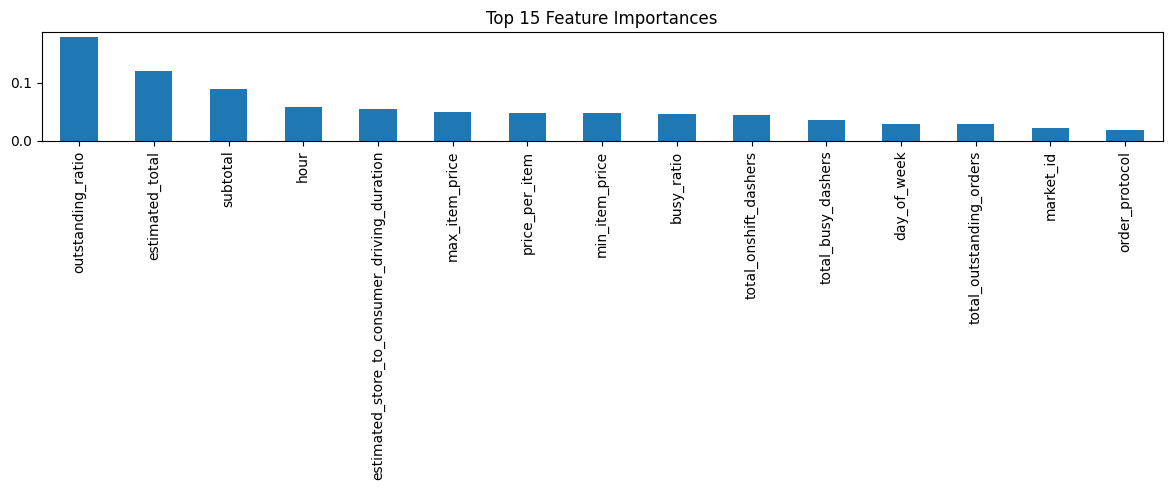

In [43]:
#  features importance

importances = pd.Series(rf.feature_importances_, index=FEATURES)
importances.sort_values(ascending=False).head(15).plot(kind='bar', figsize=(12,5))
plt.title("Top 15 Feature Importances")
plt.tight_layout()
plt.show()

c:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but GradientBoostingRegressor was fitted without feature names
  warnings.warn(


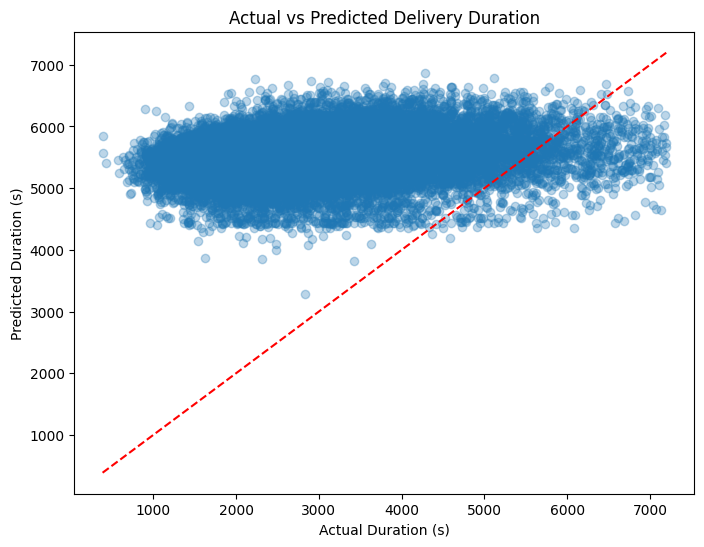

In [44]:
# visualize predictions
preds = gb.predict(X_test)

plt.figure(figsize=(8,6))
plt.scatter(y_test, preds, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Duration (s)")
plt.ylabel("Predicted Duration (s)")
plt.title("Actual vs Predicted Delivery Duration")
plt.show()